# SC5006 Project 1 — CountGD Component Analysis and Open-World Counting

**Team size:** 1–5 students  
**Foundation model:** [CountGD](https://github.com/niki-amini-naieni/CountGD), NeurIPS 2024  
**Test images:** `women.jpg` and `car.jpg`  
**Required evidence:** component shapes/visualizations, live-model predictions, quantitative results, and failure analysis

The project studies five linked CountGD components. A five-person team should assign one primary owner to each component; smaller teams combine roles. Every member must understand the integrated pipeline and speak during the oral presentation.

| Role | Assessed component | Main evidence |
|---|---|---|
| A | Image encoder | multi-scale features and combined 1/8-scale feature map |
| B | Text encoder | tokenization, masks, and projected BERT tokens |
| C | ROIAlign | pixel-space exemplar box and extracted visual token |
| D | Similarity matrix | query–prompt logits and padding mask |
| E | Top-K selection | ranked encoder proposals and prompt IDs |

The shared integration experiment runs the official CountGD checkpoint on women (text prompt) and cars (text-only, exemplar-only, and multimodal prompts), then applies the official confidence threshold and counting rule.

## Deliverables

Submit three files named with your team name:

1. `TeamXX_SC5006_Project1.ipynb` — completed code, outputs, plots, and brief interpretations.
2. `TeamXX_SC5006_Project1_Report.pdf` — Title, Authors, Introduction, Related Work, Method, Experiments, Results and Discussion, Conclusion, References, and contribution statement.
3. `TeamXX_SC5006_Project1_Presentation.pptx` — a 10-minute oral presentation; 1-2 members do the presentation; but all members must join the Q&A.

The report should be 6–8 pages excluding references/appendix. The presentation should contain 8–15 content slides. Results must distinguish live-model evidence from cached reference outputs.


## 0. Environment and model setup

Run the cell below from the project folder. It downloads the official CountGD FSC-147 checkpoint and BERT encoder only when missing, verifies the checkpoint SHA-256, loads all model weights, and prints the active paths and device. Internet access is needed only for the first run.


In [3]:
from pathlib import Path
import hashlib, importlib, os, subprocess, sys, time, warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import torch
import torch.nn.functional as F

warnings.filterwarnings("ignore")

# Open the notebook from the distributed project folder.
ROOT = Path.cwd().resolve()
if not (ROOT / "assets/reference/car.jpg").is_file():
    raise FileNotFoundError("Open this notebook from the Project 1 folder.")

ASSETS = ROOT / "assets/reference"
OUTPUT = ROOT / "output/figures"
CHECKPOINTS = ROOT / "checkpoints"
CHECKPOINT = CHECKPOINTS / "checkpoint_fsc147_best.pth"
BERT = CHECKPOINTS / "bert-base-uncased"
COUNTGD_ROOT = ROOT / "vendor/countgd"
OUTPUT.mkdir(parents=True, exist_ok=True)
CHECKPOINTS.mkdir(parents=True, exist_ok=True)

CHECKPOINT_FILE_ID = "1RbRcNLsOfeEbx6u39pBehqsgQiexHHrI"
EXPECTED_CHECKPOINT_SHA256 = "c1bab864b17db345b4c6e3aaabb5765bc2c0a90d0bc8defb5e664a74a50aa126"

def require_package(module, package=None):
    try:
        return importlib.import_module(module)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package or module])
        return importlib.import_module(module)

def download_missing_assets():
    if not CHECKPOINT.is_file():
        print("Downloading the official CountGD FSC-147 checkpoint (1.2 GB)...")
        gdown = require_package("gdown")
        result = gdown.download(id=CHECKPOINT_FILE_ID, output=str(CHECKPOINT), quiet=False)
        if not result or not CHECKPOINT.is_file():
            raise RuntimeError("Official CountGD checkpoint download failed.")
    if not (BERT / "config.json").is_file():
        print("Downloading the official BERT base encoder...")
        huggingface_hub = require_package("huggingface_hub")
        huggingface_hub.snapshot_download(
            repo_id="google-bert/bert-base-uncased", local_dir=str(BERT)
        )

def sha256_file(path, chunk_size=8 * 1024 * 1024):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

download_missing_assets()
CHECKPOINT_SHA256 = sha256_file(CHECKPOINT)
if CHECKPOINT_SHA256 != EXPECTED_CHECKPOINT_SHA256:
    raise RuntimeError(f"Incorrect CountGD checkpoint SHA-256: {CHECKPOINT_SHA256}")
if not (COUNTGD_ROOT / "models/GroundingDINO/groundingdino.py").is_file():
    raise FileNotFoundError("The distributed official source snapshot vendor/countgd is incomplete.")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sys.path.insert(0, str(COUNTGD_ROOT))
import datasets_inference.transforms as T
from util.slconfig import SLConfig
from util.misc import nested_tensor_from_tensor_list
from models.GroundingDINO.groundingdino import build_groundingdino
from models.GroundingDINO.bertwarper import generate_masks_with_special_tokens_and_transfer_map
from torchvision.ops import roi_align

TRANSFORM = T.Compose([
    T.RandomResize([800], max_size=1333),
    T.Compose([T.ToTensor(), T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]),
])

def prepare_case(name, image_name, text="", boxes=()):
    image = Image.open(ASSETS / image_name).convert("RGB")
    clean = " ".join(text.lower().strip().rstrip(".").split())
    boxes = torch.as_tensor(boxes, dtype=torch.float32).reshape(-1, 4)
    if len(boxes) > 3:
        raise ValueError("CountGD supports at most three exemplars")
    if boxes.numel():
        x1, y1, x2, y2 = boxes.unbind(1)
        valid = (x2 > x1) & (y2 > y1) & (x1 >= 0) & (y1 >= 0) & (x2 <= image.width) & (y2 <= image.height)
        if not bool(valid.all()):
            raise ValueError("Exemplars must be positive-area pixel xyxy boxes inside the image")
    mode = "text + exemplar" if clean and len(boxes) else ("text only" if clean else "exemplar only")
    return {"name": name, "image_name": image_name, "image": image,
            "caption": f"{clean} ." if clean else "object .", "boxes": boxes, "mode": mode}

def preprocess_case(case):
    image_tensor, target = TRANSFORM(case["image"], {"exemplars": case["boxes"].clone()})
    return image_tensor, target["exemplars"].to(torch.float32).reshape(-1, 4)

def load_model():
    cfg = SLConfig.fromfile(str(COUNTGD_ROOT / "config/cfg_fsc147_vit_b.py"))
    cfg.device, cfg.text_encoder_type = str(DEVICE), str(BERT)
    model, _, _ = build_groundingdino(cfg)
    message = model.load_state_dict(torch.load(CHECKPOINT, map_location="cpu")["model"], strict=False)
    if message.missing_keys or message.unexpected_keys:
        raise RuntimeError(f"Checkpoint mismatch: {message}")
    return model.to(DEVICE).eval()

CASES = [
    prepare_case("women_text", "women.jpg", text="women"),
    prepare_case("car_text", "car.jpg", text="car"),
    prepare_case("car_exemplar", "car.jpg", boxes=[[55, 72, 151, 218]]),
    prepare_case("car_multimodal", "car.jpg", text="car", boxes=[[55, 72, 151, 218]]),
]
MODEL = load_model()
print("team project root:", ROOT)
print("CountGD source:", COUNTGD_ROOT)
print("checkpoint:", CHECKPOINT)
print("checkpoint SHA-256:", CHECKPOINT_SHA256)
print("BERT:", BERT)
print("device:", DEVICE, "| live official model: True")
for case in CASES:
    print(case["name"], case["mode"], repr(case["caption"]), tuple(case["boxes"].shape))


final text_encoder_type: C:\Users\wikto\Downloads\project 1_multimodal_counting\project 1_multimodal_counting\checkpoints\bert-base-uncased
load tokenizer done.
final text_encoder_type: C:\Users\wikto\Downloads\project 1_multimodal_counting\project 1_multimodal_counting\checkpoints\bert-base-uncased
load tokenizer done.
team project root: C:\Users\wikto\Downloads\project 1_multimodal_counting\project 1_multimodal_counting
CountGD source: C:\Users\wikto\Downloads\project 1_multimodal_counting\project 1_multimodal_counting\vendor\countgd
checkpoint: C:\Users\wikto\Downloads\project 1_multimodal_counting\project 1_multimodal_counting\checkpoints\checkpoint_fsc147_best.pth
checkpoint SHA-256: c1bab864b17db345b4c6e3aaabb5765bc2c0a90d0bc8defb5e664a74a50aa126
BERT: C:\Users\wikto\Downloads\project 1_multimodal_counting\project 1_multimodal_counting\checkpoints\bert-base-uncased
device: cpu | live official model: True
women_text text only 'women .' (0, 4)
car_text text only 'car .' (0, 4)
car_

## Task 1 — Image encoder (15%)

Implement `encode_image`. Convert a preprocessed image batch into CountGD's nested-tensor representation, run the official Swin backbone, and combine the multi-scale features into the 1/8-scale feature map used for exemplar extraction.

**TODO 1**

- accept `(B,3,H,W)` or a list of `(3,H,W)` tensors;
- call `nested_tensor_from_tensor_list` and `model.backbone`;
- call `model.combine_features`;
- return the backbone features, positional encodings, and combined feature map; and
- report shapes and visualize mean feature activation.

combined image features: (1, 256, 100, 134)


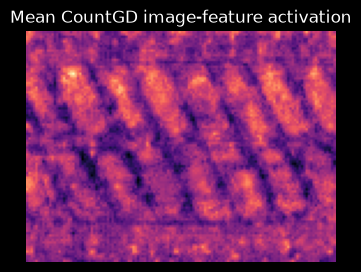

In [4]:
def encode_image(model, image_batch):
    if isinstance(image_batch, torch.Tensor):
        image_batch = list(image_batch)
    samples = nested_tensor_from_tensor_list(image_batch).to(DEVICE)
    with torch.inference_mode():
        features, positions = model.backbone(samples)
        combined = model.combine_features(features)
    assert combined.ndim == 4 and combined.shape[1] == model.hidden_dim
    return features, positions, combined

car_tensor, car_boxes_resized = preprocess_case(CASES[-1])
IMAGE_FEATURES, IMAGE_POSITIONS, COMBINED_FEATURES = encode_image(MODEL, car_tensor.unsqueeze(0))
print("combined image features:", tuple(COMBINED_FEATURES.shape))
plt.figure(figsize=(6, 3)); plt.imshow(COMBINED_FEATURES[0].mean(0).detach().cpu(), cmap="magma")
plt.title("Mean CountGD image-feature activation"); plt.axis("off"); plt.show()


## Task 2 — Text encoder (15%)

Implement `encode_text` by reproducing CountGD's caption path: tokenize, build special-token attention structures, run BERT, and project the last hidden state to the shared model dimension.

**TODO 2**

- tokenize a caption batch with padding;
- build self-attention masks and position IDs using the repository helper;
- run `model.bert` and `model.feat_map`;
- return encoded prompt tokens and the valid-token mask; and
- identify which columns correspond to real prompt tokens rather than padding.

In [5]:
def encode_text(model, captions):
    tokenized = model.tokenizer(captions, padding="longest", return_tensors="pt").to(DEVICE)
    self_masks, position_ids, _ = generate_masks_with_special_tokens_and_transfer_map(
        tokenized, model.specical_tokens, model.tokenizer)
    tokenized_for_encoder = {k: v for k, v in tokenized.items() if k != "attention_mask"}
    tokenized_for_encoder["attention_mask"] = self_masks
    tokenized_for_encoder["position_ids"] = position_ids
    with torch.inference_mode():
        bert_output = model.bert(**tokenized_for_encoder)
        encoded = model.feat_map(bert_output["last_hidden_state"])
    valid = tokenized.attention_mask.bool()
    return {"encoded_text": encoded, "text_token_mask": valid,
            "position_ids": position_ids, "text_self_attention_masks": self_masks,
            "input_ids": tokenized.input_ids}

TEXT_DICT = encode_text(MODEL, ["car ."])
print("encoded text:", tuple(TEXT_DICT["encoded_text"].shape),
      "valid tokens:", int(TEXT_DICT["text_token_mask"].sum()))


encoded text: (1, 4, 256) valid tokens: 4


### Task 3 — ROIAlign visual exemplar tokens (15%)

Use pixel-space exemplar boxes and `roi_align` with `output_size=(1,1)`, `spatial_scale=1/8`, and `aligned=True`, then reshape the result to `(B,N,D)`.


In [6]:
def extract_exemplar_tokens(combined_features, exemplar_boxes):
    if combined_features.ndim != 4 or len(exemplar_boxes) != combined_features.shape[0]:
        raise ValueError("Expected features (B,D,H,W) and one (N,4) box tensor per image")
    counts = [len(boxes) for boxes in exemplar_boxes]
    if len(set(counts)) != 1 or counts[0] == 0:
        raise ValueError("This exercise expects the same positive exemplar count per image")
    tokens = roi_align(combined_features, boxes=exemplar_boxes, output_size=(1, 1),
                       spatial_scale=1/8, aligned=True).squeeze(-1).squeeze(-1)
    return tokens.reshape(combined_features.shape[0], counts[0], -1)

EXEMPLAR_TOKENS = extract_exemplar_tokens(COMBINED_FEATURES, [car_boxes_resized.to(COMBINED_FEATURES.device)])
print("resized exemplar:", car_boxes_resized.tolist())
print("ROIAlign exemplar token:", tuple(EXEMPLAR_TOKENS.shape))


resized exemplar: [[95.8006591796875, 125.49020385742188, 263.016357421875, 379.9564514160156]]
ROIAlign exemplar token: (1, 1, 256)


### Task 4 — Similarity matrix calculation (15%)

Compute query–prompt dot products, mask padded prompt columns with `-inf`, and visualize the valid part of the similarity matrix.


similarity matrix: (1, 13400, 5)


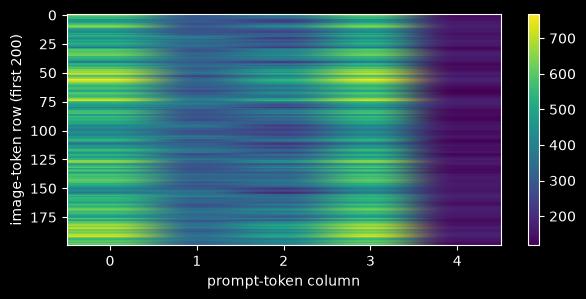

In [8]:
def calculate_similarity_matrix(query_features, prompt_features, prompt_mask):
    if query_features.ndim != 3 or prompt_features.ndim != 3:
        raise ValueError("Expected query (B,N,D) and prompt (B,T,D)")
    if query_features.shape[0] != prompt_features.shape[0] or query_features.shape[-1] != prompt_features.shape[-1]:
        raise ValueError("Batch and feature dimensions must agree")
    if prompt_mask.shape != prompt_features.shape[:2]:
        raise ValueError("Prompt mask must have shape (B,T)")
    logits = query_features @ prompt_features.transpose(-1, -2)
    return logits.masked_fill(~prompt_mask[:, None, :], float("-inf"))

IMAGE_TOKENS = COMBINED_FEATURES.flatten(2).transpose(1, 2)
PROMPT_TOKENS = torch.cat([TEXT_DICT["encoded_text"].to(IMAGE_TOKENS.device), EXEMPLAR_TOKENS], dim=1)
PROMPT_MASK = torch.cat([TEXT_DICT["text_token_mask"].to(IMAGE_TOKENS.device),
                         torch.ones((1, EXEMPLAR_TOKENS.shape[1]), dtype=torch.bool, device=IMAGE_TOKENS.device)], dim=1)
SIMILARITY = calculate_similarity_matrix(IMAGE_TOKENS, PROMPT_TOKENS, PROMPT_MASK)
print("similarity matrix:", tuple(SIMILARITY.shape))
plt.figure(figsize=(7, 3)); plt.imshow(SIMILARITY[0, :200].detach().cpu(), aspect="auto", cmap="viridis")
plt.xlabel("prompt-token column"); plt.ylabel("image-token row (first 200)"); plt.colorbar(); plt.show()


### Task 5 — Top-K encoder proposal selection (15%)

Reduce each proposal to its strongest prompt score, apply `topk` over proposals, and report the winning proposal IDs and prompt IDs.


In [11]:
def select_topk(similarity, k):
    if similarity.ndim != 3 or not 1 <= k <= similarity.shape[1]:
        raise ValueError("Expected (B,N,T) similarities and 1 <= k <= N")
    proposal_scores, prompt_ids = similarity.max(dim=-1)
    scores, proposal_ids = torch.topk(proposal_scores, k, dim=1)
    selected_prompt_ids = torch.gather(prompt_ids, 1, proposal_ids)
    return scores, proposal_ids, selected_prompt_ids

TOPK_SCORES, TOPK_PROPOSALS, TOPK_PROMPTS = select_topk(SIMILARITY, 10)
print("top-K proposal IDs:", TOPK_PROPOSALS.tolist())
print("winning prompt IDs:", TOPK_PROMPTS.tolist())


top-K proposal IDs: [[13396, 13395, 13394, 657, 13038, 326, 13257, 13172, 13241, 13261]]
winning prompt IDs: [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]


### Task 6 — Shared integration experiment and results (25%)

Run the official model on all four prompt cases and include counts, localization plots at threshold `0.23`, component shapes, one ablation, runtime/hardware, and one failure case.

**TODO 6A — Prompt sensitivity experiment**

- create new text-only cases without changing the source images: `women → man` and `car → yellow car`;
- run each changed prompt through the live CountGD model using the same preprocessing and post-processing;
- report the changed captions, counts, scores, boxes, and localization plots; and
- compare each changed-prompt result with its original-prompt baseline.

Changed prompts require a live model forward pass. Run fresh inference for `man` and `yellow car`; do not reuse predictions from another query.


women_text 'women' LIVE (900, 256) (900, 4) count= 5 time=10.25s
car_text 'car' LIVE (900, 256) (900, 4) count= 16 time=20.58s
car_exemplar '' LIVE (900, 256) (900, 4) count= 16 time=21.59s
car_multimodal 'car' LIVE (900, 256) (900, 4) count= 16 time=21.65s


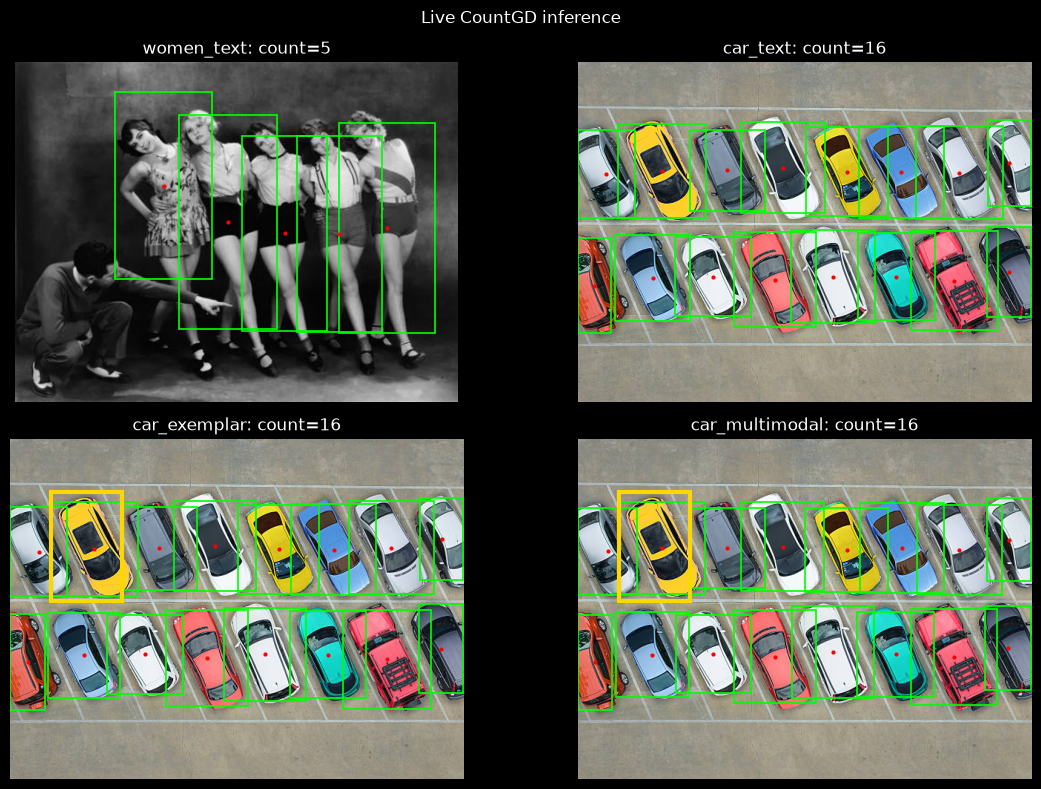

In [12]:
# Task 6 reuses prepare_case and preprocess_case from Section 0.
# The official forward pass internally executes the components studied in Tasks 1–5.
def run_countgd(model, image_name, query="", exemplar_boxes=()):
    case_name = f"{Path(image_name).stem}_{query or 'exemplar'}".replace(" ", "_")
    case = prepare_case(case_name, image_name, text=query, boxes=exemplar_boxes)
    image_tensor, boxes = preprocess_case(case)
    model.drop_text = case["mode"] == "exemplar only"
    with torch.inference_mode():
        output = model(
            image_tensor.unsqueeze(0).to(DEVICE),
            [boxes.to(DEVICE)],
            [torch.tensor([0], device=DEVICE)],
            captions=[case["caption"]],
        )
    assert tuple(output["pred_logits"].shape[1:]) == (900, 256)
    assert tuple(output["pred_boxes"].shape[1:]) == (900, 4)
    raw = {
        "confidences": output["pred_logits"][0].sigmoid().cpu().numpy().astype(np.float32),
        "boxes": output["pred_boxes"][0].cpu().numpy().astype(np.float32),
        "image_size": (case["image"].height, case["image"].width),
    }
    return case, raw

def postprocess_countgd(raw, threshold=0.23):
    confidences, boxes = raw["confidences"], raw["boxes"]
    finite = np.isfinite(confidences).all(1) & np.isfinite(boxes).all(1)
    scores = np.where(finite[:, None], confidences, -np.inf).max(1)
    keep = finite & (scores > threshold)
    scores, boxes = scores[keep], boxes[keep]
    h, w = raw["image_size"]
    cx, cy, bw, bh = boxes.T
    xyxy = np.column_stack([(cx-bw/2)*w, (cy-bh/2)*h, (cx+bw/2)*w, (cy+bh/2)*h])
    xyxy[:, [0, 2]] = np.clip(xyxy[:, [0, 2]], 0, w-1)
    xyxy[:, [1, 3]] = np.clip(xyxy[:, [1, 3]], 0, h-1)
    centers = np.column_stack([(xyxy[:, 0]+xyxy[:, 2])/2, (xyxy[:, 1]+xyxy[:, 3])/2])
    return {"scores": scores, "boxes": xyxy, "centers": centers, "count": len(scores)}

def predict_countgd(image_name, query="", exemplar_boxes=(), threshold=0.23):
    case, raw = run_countgd(MODEL, image_name, query, exemplar_boxes)
    return {"case": case, "raw": raw, "result": postprocess_countgd(raw, threshold)}

# Text inference needs only the image filename and query. Boxes are optional for exemplar modes.
REQUESTS = [
    ("women_text", "women.jpg", "women", ()),
    ("car_text", "car.jpg", "car", ()),
    ("car_exemplar", "car.jpg", "", [[55, 72, 151, 218]]),
    ("car_multimodal", "car.jpg", "car", [[55, 72, 151, 218]]),
]

PREDICTIONS = {}
for name, image_name, query, exemplar_boxes in REQUESTS:
    t0 = time.time()
    PHRASE_THRESHOLD = 0.50
    prediction = predict_countgd(image_name, query, exemplar_boxes, threshold=PHRASE_THRESHOLD)
    PREDICTIONS[name] = prediction
    print(name, repr(query), "LIVE", prediction["raw"]["confidences"].shape,
          prediction["raw"]["boxes"].shape, "count=", prediction["result"]["count"],
          f"time={time.time()-t0:.2f}s")

# Keep these aliases for the prompt-sensitivity experiment below.
RAW = {name: value["raw"] for name, value in PREDICTIONS.items()}
RESULTS = {name: value["result"] for name, value in PREDICTIONS.items()}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (name, prediction) in zip(axes.flat, PREDICTIONS.items()):
    case, result = prediction["case"], prediction["result"]
    ax.imshow(case["image"])
    for score, (x1, y1, x2, y2), (x, y) in zip(result["scores"], result["boxes"], result["centers"]):
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, ec="lime", lw=1.2))
        ax.plot(x, y, "r.", ms=4)
    for x1, y1, x2, y2 in case["boxes"]:
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, ec="gold", lw=3))
    ax.set_title(f"{name}: count={result['count']}")
    ax.axis("off")
fig.suptitle("Live CountGD inference")
fig.tight_layout()
fig.savefig(OUTPUT / "official_countgd_car_women_tests.png", dpi=170, bbox_inches="tight")
plt.show()


women_as_man 'man .' tokens= ['man'] count= 1
car_as_yellow_car 'yellow car .' tokens= ['yellow', 'car'] count= 2


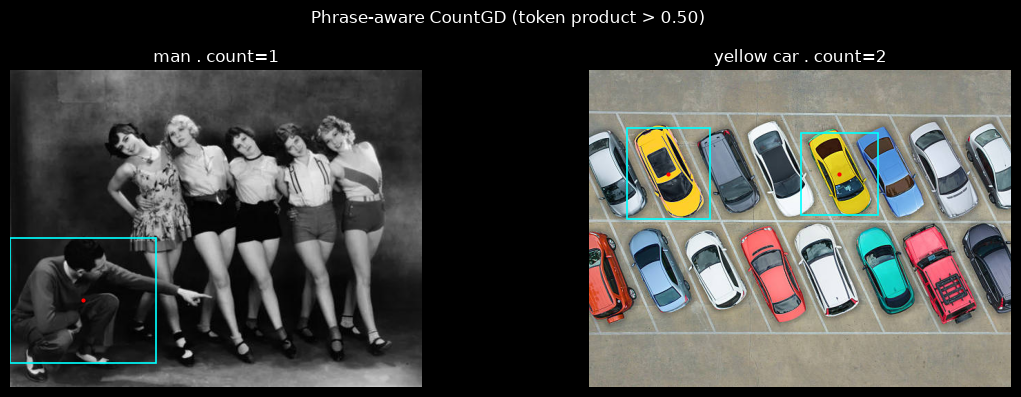

In [13]:
PROMPT_VARIANTS = [
    prepare_case("women_as_man", "women.jpg", text="man"),
    prepare_case("car_as_yellow_car", "car.jpg", text="yellow car"),
]

def phrase_token_indices(model, caption):
    encoded = model.tokenizer(caption)
    tokens = model.tokenizer.convert_ids_to_tokens(encoded["input_ids"])
    ignored = set(model.tokenizer.all_special_tokens) | {".", ",", ";", ":", "!", "?"}
    indices = [index for index, token in enumerate(tokens) if token not in ignored]
    if not indices:
        raise ValueError(f"No meaningful text tokens found in {caption!r}")
    return indices, [tokens[index] for index in indices]

def postprocess_phrase_query(raw, model, caption, threshold=0.50):
    indices, tokens = phrase_token_indices(model, caption)
    phrase_scores = raw["confidences"][:, indices].prod(axis=1, dtype=np.float32)
    phrase_raw = {**raw, "confidences": phrase_scores[:, None]}
    result = postprocess_countgd(phrase_raw, threshold)
    result["phrase_tokens"] = tokens
    return result

def evaluate_prompt_variants(model, prompt_cases, threshold=0.50):
    if model is None:
        raise RuntimeError("Changed prompts require fresh live-model inference.")
    evaluated = {}
    for case in prompt_cases:
        query = case["caption"][:-2] if case["caption"].endswith(" .") else case["caption"]
        _, raw = run_countgd(model, case["image_name"], query, case["boxes"])
        result = postprocess_phrase_query(raw, model, case["caption"], threshold)
        evaluated[case["name"]] = {"raw": raw, "result": result}
    return evaluated

PHRASE_THRESHOLD = 0.50
PROMPT_RESULTS = evaluate_prompt_variants(MODEL, PROMPT_VARIANTS, PHRASE_THRESHOLD)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, case in zip(axes, PROMPT_VARIANTS):
    result = PROMPT_RESULTS[case["name"]]["result"]
    ax.imshow(case["image"])
    for score, (x1, y1, x2, y2), (x, y) in zip(
        result["scores"], result["boxes"], result["centers"]
    ):
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, ec="cyan", lw=1.2))
        ax.plot(x, y, "r.", ms=4)
    ax.set_title(f"{case['caption']} count={result['count']}")
    ax.axis("off")
    print(case["name"], repr(case["caption"]),
          "tokens=", result["phrase_tokens"], "count=", result["count"])
fig.suptitle(f"Phrase-aware CountGD (token product > {PHRASE_THRESHOLD:.2f})")
fig.tight_layout()
fig.savefig(OUTPUT / "countgd_changed_text_prompts.png", dpi=170, bbox_inches="tight")
plt.show()